In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.nn.utils.parametrizations import weight_norm
from torchvision import transforms, datasets
from matplotlib import pyplot as plt
from tqdm import tqdm
import sys, os
sys.path.append(os.path.abspath("../../lib"))
import util
import importlib
importlib.reload(util)

<module 'util' from 'C:\\Users\\amand\\Documents\\Research\\Project_LIDI\\VAE_Tutorials\\lib\\util.py'>

# Introduction
We compare different aspects of the VAE architecture for MNIST.
1. Activation function (lrelu slope)
2. Hidden dimension
3. Number hidden layers
4. Normalization (batch vs weight)
5. Learning rate


# Setup

### MLP network

In [2]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, **kwargs):
        super().__init__()

        activation = kwargs.get('activation')
        slope = kwargs.get('lrelu_slope')
        hidden = kwargs.get('hidden_dim')
        num_layers = kwargs.get('num_layers')
        norm_type = kwargs.get('norm_type')

        hidden_dims = num_layers * [hidden]
        hidden_dims = [in_dim] + hidden_dims

        # Define middle layers
        layer_lst = []
        for n in range(num_layers):
            # Linear layer (possibly w normalization)
            if norm_type == 'none':
                layer_lst.append(nn.Linear(hidden_dims[n], hidden_dims[n + 1]))
            elif norm_type == 'weight':
                layer_lst.append(weight_norm(nn.Linear(hidden_dims[n], hidden_dims[n + 1])))
            elif norm_type == 'batch':
                layer_lst.append(nn.Linear(hidden_dims[n], hidden_dims[n + 1]))
                layer_lst.append(nn.BatchNorm1d(hidden_dims[n+1]))
            elif norm_type == 'batch_weight':
                layer_lst.append(weight_norm(nn.Linear(hidden_dims[n], hidden_dims[n + 1])))
                layer_lst.append(nn.BatchNorm1d(hidden_dims[n + 1]))

            # Activation type
            if activation == 'leaky_relu':
                layer_lst.append(nn.LeakyReLU(slope))
            elif activation == 'relu':
                layer_lst.append(nn.ReLU())
            elif activation == 'tanh':
                layer_lst.append(nn.Tanh())
            elif activation == 'sigmoid':
                layer_lst.append(nn.Sigmoid())

        self.layers = nn.Sequential(*layer_lst)

        # Define output layers
        self.mu = nn.Linear(hidden_dims[-1], out_dim)
        self.log_var = nn.Linear(hidden_dims[-1], out_dim)

    def forward(self, x):
        out = self.layers(x)
        return self.mu(out), self.log_var(out)

### VAE model

In [3]:
class VAE(nn.Module):
    def __init__(self, kx, **kwargs):
        super().__init__()
        self.kx = kx

        self.pz = kwargs.get('pz')

        self.encoder = MLP(kx, self.pz, **kwargs)
        self.decoder = MLP(self.pz, kx, **kwargs)

    def forward(self, x):
        self.mu_e, self.logvar_e = self.encoder(x)
        self.z = util.sample(self.mu_e, self.logvar_e)
        self.mu_d, self.logvar_d = self.decoder(self.z)

        return self.mu_e, self.logvar_e

    def loss(self, x):
        recon = -1 * util.normal_ll(x, self.mu_d, self.logvar_d)
        kl_div = util.kl_normal(self.mu_e, self.logvar_e, torch.zeros_like(self.mu_e), torch.ones_like(self.logvar_e))

        return recon.mean(), kl_div.mean()

    def get_z_samples(self):
        return self.z.detach().cpu()

### Prepare for training

In [4]:
# Load CPU or GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CUDA


In [5]:
# General training settings
cfg = {
    'rng': 1,
    'batch_size': 128,
    'epochs': 10,
    'lr': 0.001,
    'data_src': 'ivae1',
    'pz': 8,
    'activation': 'leaky_relu',
    'lrelu_slope': 0.01,
    'hidden_dim': 256,
    'num_layers': 2,
    'norm_type': 'none'
}

# Set random seed
torch.manual_seed(cfg['rng'])
np.random.seed(cfg['rng'])

In [6]:
# Load dataset
data, kx = util.get_dataset(**cfg)
generator = torch.Generator().manual_seed(cfg['rng'])
train_data, valid_data, test_data = random_split(data, [0.8, 0.1, 0.1], generator=generator)
train_loader = DataLoader(train_data, cfg['batch_size'], shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data))

# Investigation 1: Activation function

### Training

In [7]:
# Model 1a: leaky relu with slope 0.01
model_1a = VAE(kx, **cfg).to(device)
optimizer = torch.optim.Adam(params=model_1a.parameters(), lr=cfg['lr'])
util.get_num_parameters(model_1a)

recon_1a, kl_1a, metrics_1a = util.train_vae(model_1a, optimizer, train_loader, device, **cfg)

Number of parameters: 141336


100%|██████████| 10/10 [00:07<00:00,  1.31it/s]


In [8]:
# Model 1b: leaky relu with slope 1
cfg['lrelu_slope'] = 1

model_1b = VAE(kx, **cfg).to(device)
optimizer = torch.optim.Adam(params=model_1b.parameters(), lr=cfg['lr'])
util.get_num_parameters(model_1b)

recon_1b, kl_1b, metrics_1b = util.train_vae(model_1b, optimizer, train_loader, device, **cfg)

Number of parameters: 141336


100%|██████████| 10/10 [00:08<00:00,  1.18it/s]


In [9]:
# Model 1c: relu
cfg['activation'] = 'relu'

model_1c = VAE(kx, **cfg).to(device)
optimizer = torch.optim.Adam(params=model_1c.parameters(), lr=cfg['lr'])
util.get_num_parameters(model_1c)

recon_1c, kl_1c, metrics_1c = util.train_vae(model_1c, optimizer, train_loader, device, **cfg)

Number of parameters: 141336


100%|██████████| 10/10 [00:09<00:00,  1.09it/s]


In [10]:
# Model 1d: tanh
cfg['activation'] = 'tanh'

model_1d = VAE(kx, **cfg).to(device)
optimizer = torch.optim.Adam(params=model_1d.parameters(), lr=cfg['lr'])
util.get_num_parameters(model_1d)

recon_1d, kl_1d, metrics_1d = util.train_vae(model_1d, optimizer, train_loader, device, **cfg)

Number of parameters: 141336


100%|██████████| 10/10 [00:09<00:00,  1.10it/s]


In [11]:
# Model 1e: sigmoid
cfg['activation'] = 'sigmoid'

model_1e = VAE(kx, **cfg).to(device)
optimizer = torch.optim.Adam(params=model_1e.parameters(), lr=cfg['lr'])
util.get_num_parameters(model_1e)

recon_1e, kl_1e, metrics_1e = util.train_vae(model_1e, optimizer, train_loader, device, **cfg)

Number of parameters: 141336


100%|██████████| 10/10 [00:09<00:00,  1.11it/s]


### Plot training loss

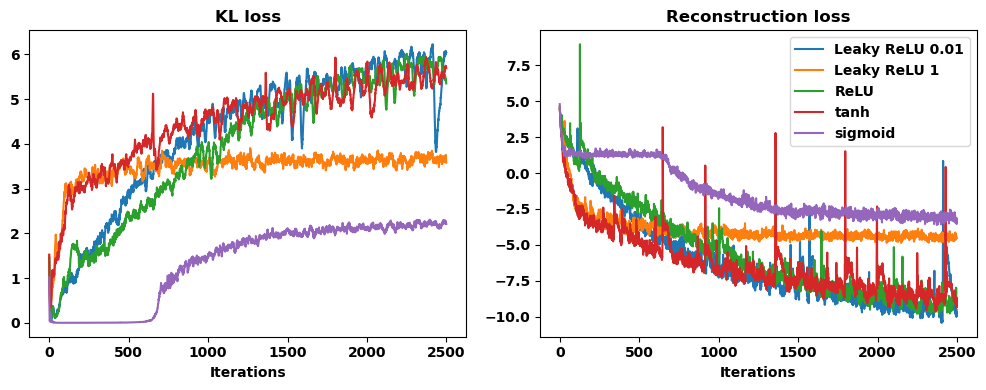

In [12]:
recon_arr = [recon_1a, recon_1b, recon_1c, recon_1d, recon_1e]
kl_arr = [kl_1a, kl_1b, kl_1c, kl_1d, kl_1e]
activations = ["Leaky ReLU 0.01", "Leaky ReLU 1", "ReLU", "tanh", "sigmoid"]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for i in range(len(recon_arr)):
    axs[0].plot(kl_arr[i], label=activations[i])
    axs[1].plot(recon_arr[i], label=activations[i])
axs[0].set_xlabel("Iterations")
axs[0].set_title("KL loss")
axs[1].set_xlabel("Iterations")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.tight_layout()

### Plot mutual information

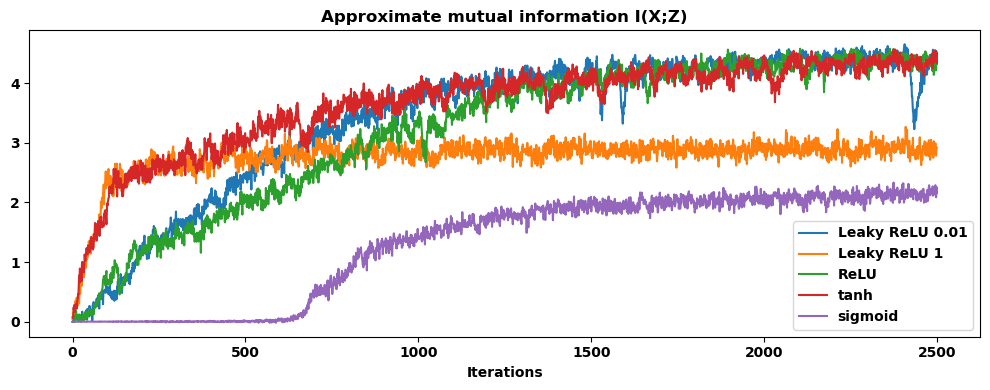

In [13]:
metrics_arr = [metrics_1a, metrics_1b, metrics_1c, metrics_1d, metrics_1e]
activations = ["Leaky ReLU 0.01", "Leaky ReLU 1", "ReLU", "tanh", "sigmoid"]

fig, axs = plt.subplots(1, 1, figsize=(10, 4))

for i in range(len(recon_arr)):
    axs.plot(metrics_arr[i]['ami'], label=activations[i])
axs.set_xlabel("Iterations")
axs.set_title("Approximate mutual information I(X;Z)")
plt.legend()
plt.tight_layout()

# Investigation 2: Hidden layer dimension

In [14]:
# Reset
cfg = {
    'rng': 1,
    'batch_size': 128,
    'epochs': 10,
    'lr': 0.001,
    'data_src': 'ivae1',
    'pz': 8,
    'activation': 'leaky_relu',
    'lrelu_slope': 0.01,
    'hidden_dim': 256,
    'num_layers': 2,
    'norm_type': 'none'
}

### Training

In [15]:
hidden_dims = [256, 128, 32, 8, 2]

recon_arr, kl_arr, metrics_arr = [], [], []

for i in hidden_dims:
    # Define model
    cfg['hidden_dim'] = i
    model = VAE(kx, **cfg).to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
    util.get_num_parameters(model)

    # Train
    recon, kl, metrics = util.train_vae(model, optimizer, train_loader, device, **cfg)

    # Save loss
    recon_arr.append(recon)
    kl_arr.append(kl)
    metrics_arr.append(metrics)

Number of parameters: 141336


100%|██████████| 10/10 [00:09<00:00,  1.10it/s]


Number of parameters: 37912


100%|██████████| 10/10 [00:08<00:00,  1.11it/s]


Number of parameters: 3352


100%|██████████| 10/10 [00:09<00:00,  1.07it/s]


Number of parameters: 472


100%|██████████| 10/10 [00:08<00:00,  1.13it/s]


Number of parameters: 112


100%|██████████| 10/10 [00:09<00:00,  1.10it/s]


### Plot training loss

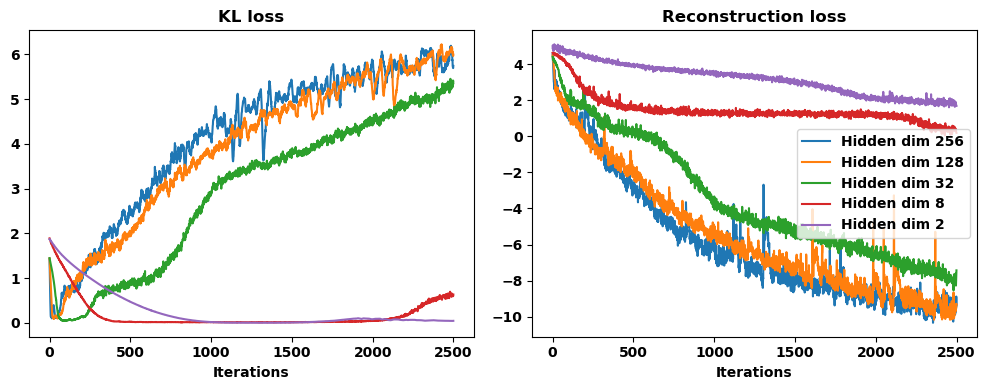

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for i in range(len(recon_arr)):
    axs[0].plot(kl_arr[i], label="Hidden dim " + str(hidden_dims[i]))
    axs[1].plot(recon_arr[i], label="Hidden dim " + str(hidden_dims[i]))
axs[0].set_xlabel("Iterations")
axs[0].set_title("KL loss")
axs[1].set_xlabel("Iterations")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.tight_layout()

### Plot mutual information

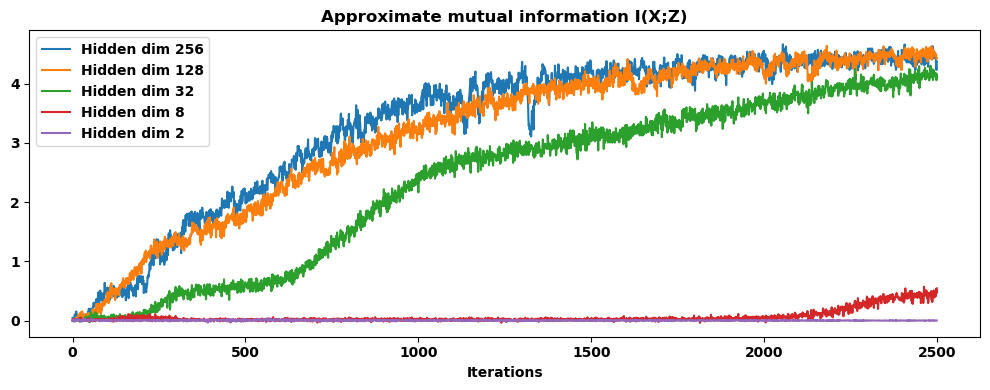

In [17]:
fig, axs = plt.subplots(1, 1, figsize=(10, 4))

for i in range(len(recon_arr)):
    axs.plot(metrics_arr[i]['ami'], label="Hidden dim " + str(hidden_dims[i]))
axs.set_xlabel("Iterations")
axs.set_title("Approximate mutual information I(X;Z)")
plt.legend()
plt.tight_layout()

# Investigation 3: Number of hidden layers

In [18]:
# Reset
cfg = {
    'rng': 1,
    'batch_size': 128,
    'epochs': 10,
    'lr': 0.001,
    'data_src': 'ivae1',
    'pz': 8,
    'activation': 'leaky_relu',
    'lrelu_slope': 0.01,
    'hidden_dim': 256,
    'num_layers': 2,
    'norm_type': 'none'
}

### Training

In [19]:
num_layers = [10, 5, 3, 2, 1]

recon_arr, kl_arr, metrics_arr = [], [], []

for i in num_layers:
    # Define model
    cfg['num_layers'] = i
    model = VAE(kx, **cfg).to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
    util.get_num_parameters(model)

    # Train
    recon, kl, metrics = util.train_vae(model, optimizer, train_loader, device, **cfg)

    # Save loss
    recon_arr.append(recon)
    kl_arr.append(kl)
    metrics_arr.append(metrics)

Number of parameters: 1194008


100%|██████████| 10/10 [00:14<00:00,  1.41s/it]


Number of parameters: 536088


100%|██████████| 10/10 [00:09<00:00,  1.07it/s]


Number of parameters: 272920


100%|██████████| 10/10 [00:08<00:00,  1.19it/s]


Number of parameters: 141336


100%|██████████| 10/10 [00:07<00:00,  1.25it/s]


Number of parameters: 9752


100%|██████████| 10/10 [00:07<00:00,  1.26it/s]


### Plot training loss

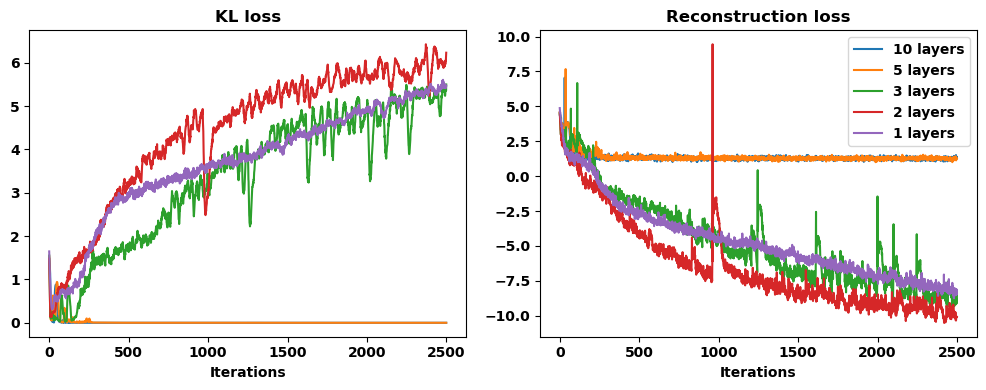

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for i in range(len(recon_arr)):
    axs[0].plot(kl_arr[i], label=str(num_layers[i]) + " layers")
    axs[1].plot(recon_arr[i], label=str(num_layers[i]) + " layers")
axs[0].set_xlabel("Iterations")
axs[0].set_title("KL loss")
axs[1].set_xlabel("Iterations")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.tight_layout()

### Plot mutual information

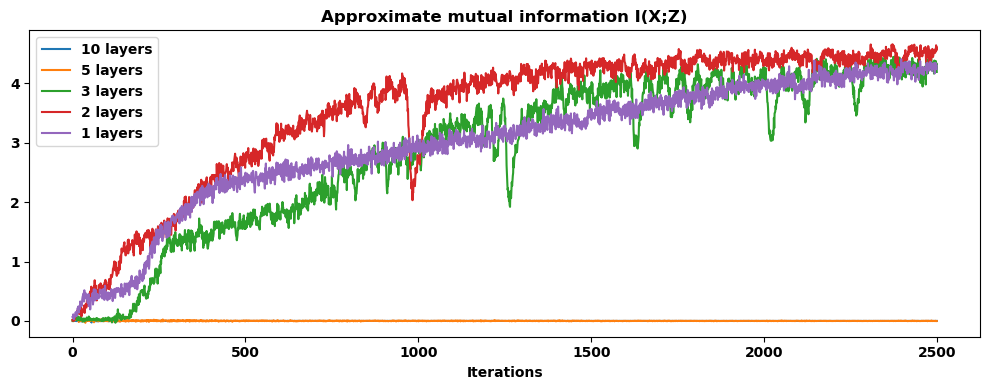

In [21]:
fig, axs = plt.subplots(1, 1, figsize=(10, 4))

for i in range(len(recon_arr)):
    axs.plot(metrics_arr[i]['ami'], label=str(num_layers[i]) + " layers")
axs.set_xlabel("Iterations")
axs.set_title("Approximate mutual information I(X;Z)")
plt.legend()
plt.tight_layout()

# Investigation 4: Normalization

In [22]:
# Reset
cfg = {
    'rng': 1,
    'batch_size': 128,
    'epochs': 10,
    'lr': 0.001,
    'data_src': 'ivae1',
    'pz': 8,
    'activation': 'leaky_relu',
    'lrelu_slope': 0.01,
    'hidden_dim': 256,
    'num_layers': 2,
    'norm_type': 'none'
}

### Training

In [23]:
norm_type = ['none', 'batch', 'weight', 'batch_weight']

recon_arr, kl_arr, metrics_arr = [], [], []

for i in norm_type:
    # Define model
    cfg['norm_type'] = i
    model = VAE(kx, **cfg).to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
    util.get_num_parameters(model)

    # Train
    recon, kl, metrics = util.train_vae(model, optimizer, train_loader, device, **cfg)

    # Save loss
    recon_arr.append(recon)
    kl_arr.append(kl)
    metrics_arr.append(metrics)

Number of parameters: 141336


100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


Number of parameters: 143384


100%|██████████| 10/10 [00:09<00:00,  1.03it/s]


Number of parameters: 142360


100%|██████████| 10/10 [00:09<00:00,  1.06it/s]


Number of parameters: 144408


100%|██████████| 10/10 [00:10<00:00,  1.07s/it]


### Plot training loss

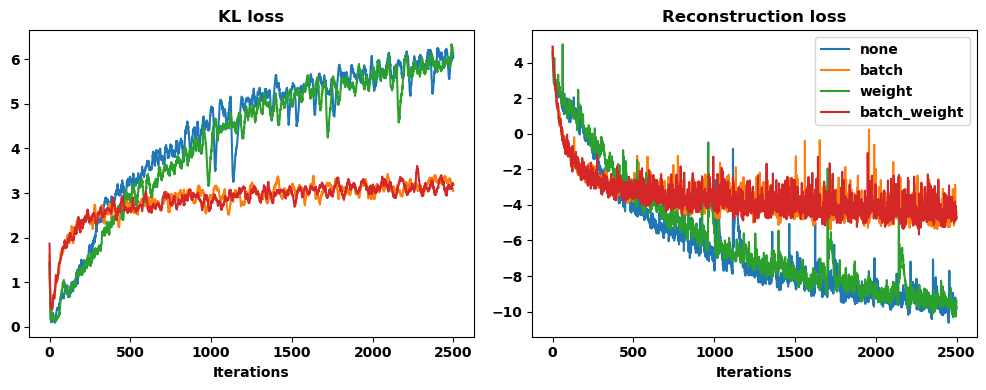

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for i in range(len(recon_arr)):
    axs[0].plot(kl_arr[i], label=norm_type[i])
    axs[1].plot(recon_arr[i], label=norm_type[i])
axs[0].set_xlabel("Iterations")
axs[0].set_title("KL loss")
axs[1].set_xlabel("Iterations")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.tight_layout()

### Plot mutual information

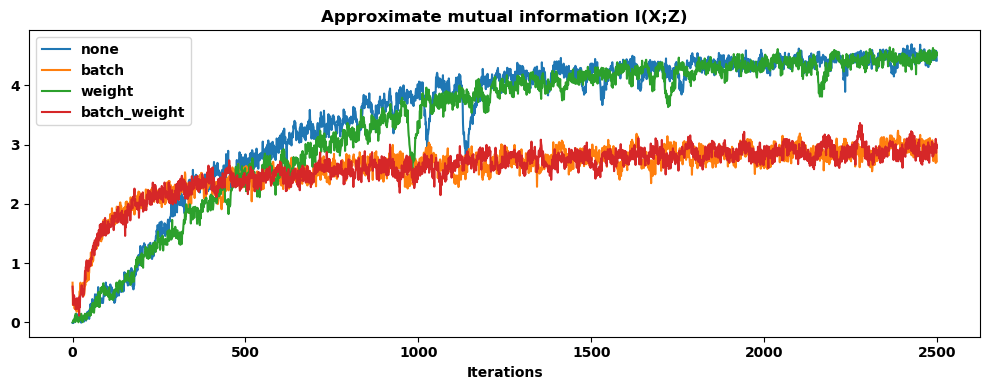

In [25]:
fig, axs = plt.subplots(1, 1, figsize=(10, 4))

for i in range(len(recon_arr)):
    axs.plot(metrics_arr[i]['ami'], label=norm_type[i])
axs.set_xlabel("Iterations")
axs.set_title("Approximate mutual information I(X;Z)")
plt.legend()
plt.tight_layout()

# Investigation 5: learning rate

In [26]:
# Reset
cfg = {
    'rng': 1,
    'batch_size': 128,
    'epochs': 10,
    'lr': 0.001,
    'data_src': 'ivae1',
    'pz': 8,
    'activation': 'leaky_relu',
    'lrelu_slope': 0.01,
    'hidden_dim': 256,
    'num_layers': 2,
    'norm_type': 'none'
}

### Training

In [27]:
lr_arr = [1e-3, 5e-4, 1e-4]

recon_arr, kl_arr, metrics_arr = [], [], []

for i in lr_arr:
    # Define model
    cfg['lr'] = i
    model = VAE(kx, **cfg).to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
    util.get_num_parameters(model)

    # Train
    recon, kl, metrics = util.train_vae(model, optimizer, train_loader, device, **cfg)

    # Save loss
    recon_arr.append(recon)
    kl_arr.append(kl)
    metrics_arr.append(metrics)

Number of parameters: 141336


100%|██████████| 10/10 [00:08<00:00,  1.13it/s]


Number of parameters: 141336


100%|██████████| 10/10 [00:08<00:00,  1.12it/s]


Number of parameters: 141336


100%|██████████| 10/10 [00:09<00:00,  1.10it/s]


### Plot training loss

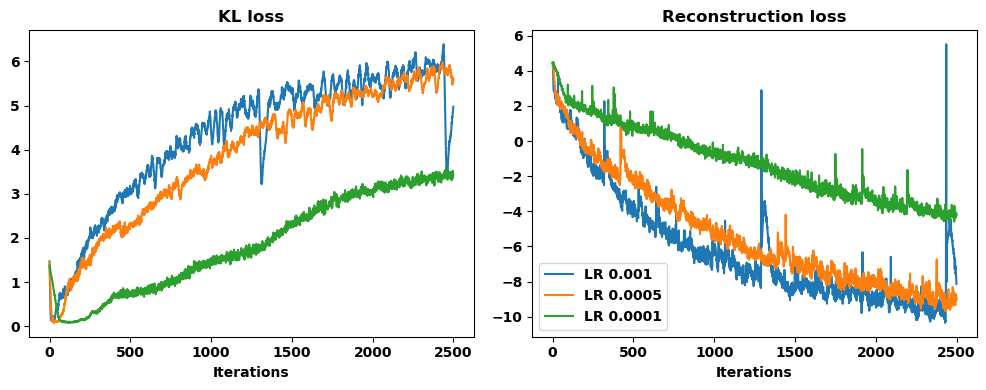

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for i in range(len(recon_arr)):
    axs[0].plot(kl_arr[i], label="LR " + str(lr_arr[i]))
    axs[1].plot(recon_arr[i], label="LR " + str(lr_arr[i]))
axs[0].set_xlabel("Iterations")
axs[0].set_title("KL loss")
axs[1].set_xlabel("Iterations")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.tight_layout()

### Plot mutual information

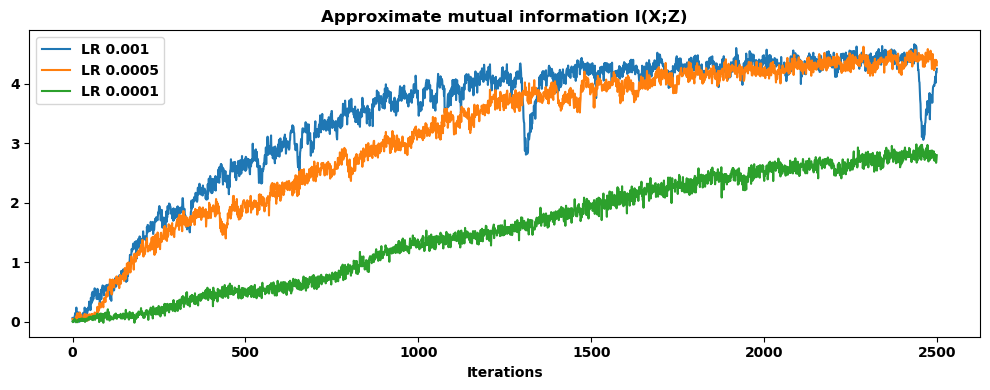

In [29]:
fig, axs = plt.subplots(1, 1, figsize=(10, 4))

for i in range(len(recon_arr)):
    axs.plot(metrics_arr[i]['ami'], label="LR " + str(lr_arr[i]))
axs.set_xlabel("Iterations")
axs.set_title("Approximate mutual information I(X;Z)")
plt.legend()
plt.tight_layout()